문제를 해결하는데 필요한 라이브러리를 호출한다.

In [ ]:
#import ~~ 문제 풀이 후 모든 라이브러리 호출을 이곳으로 모아서 정리할 것.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [ ]:
!pip install pandas
!pip install matplotlib

In [ ]:
!pip install numpy

# 문제 1. Projection Matrix 해석

이 행렬이 어떤 의미를 가지는지 설명하고, 다음을 포함하여 해석하시오.

 - intrinsic 파라미터 (f_x, f_y, c_x, c_y)의 의미
 - extrinsic 파라미터 (R, t)의 역할
 - 이 행렬이 3D 점을 이미지 좌표로 어떻게 변환하는지 수식으로 설명

In [6]:
import os 
left_image_files = os.listdir('./dataset/sequences/09/image_0')
print(left_image_files[:5])

['000000.png', '000001.png', '000002.png', '000003.png', '000004.png']


calib.txt 파일에 저장된 P0~3은 모두 카메라의 투영 행렬(projection matrix) 입니다.

투영 행렬은 카메라의 초점 거리(focal length)와 광학 중심(optical center)과 같은 내부 파라미터에 대한 정보를 포함하고 있습니다. 이 행렬을 이용해 각 카메라의 좌표계를 글로벌 좌표계, 즉 P1의 경우 왼쪽 흑백 카메라의 좌표계와 연결해 주는 변환을 할 수 있습니다.
투영 행렬은 글로벌 좌표계에 있는 3차원 좌표를 카메라의 이미지 평면 위에 투영하는 역할을 하며, 그 수식과 그림은 셋업 페이지와 함께 OpenCV를 참조하여 이해할 수 있습니다.

P0는 왼쪽 회색 카메라의 투영 행렬, P1은 오른쪽 회색 카메라의 투영 행렬입니다.

In [30]:
calib = pd.read_csv('./dataset/sequences/09/calib.txt', delimiter=' ', header=None, index_col=0)
print(calib)

           1    2         3          4    5         6         7        8   \
0                                                                           
P0:  707.0912  0.0  601.8873    0.00000  0.0  707.0912  183.1104  0.00000   
P1:  707.0912  0.0  601.8873 -379.81450  0.0  707.0912  183.1104  0.00000   
P2:  707.0912  0.0  601.8873   46.88783  0.0  707.0912  183.1104  0.11786   
P3:  707.0912  0.0  601.8873 -333.45970  0.0  707.0912  183.1104  1.93013   

      9    10   11        12  
0                             
P0:  0.0  0.0  1.0  0.000000  
P1:  0.0  0.0  1.0  0.000000  
P2:  0.0  0.0  1.0  0.006203  
P3:  0.0  0.0  1.0  0.003318  


In [43]:
P0 = np.array(calib.loc['P0:']).reshape((3,4))
P1 = np.array(calib.loc['P1:']).reshape((3,4))

print(P0)
print(P1)

[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]
[[ 707.0912    0.      601.8873 -379.8145]
 [   0.      707.0912  183.1104    0.    ]
 [   0.        0.        1.        0.    ]]


P = K · [R | t]



cv2.decomposeProjectionMatrix로 P0의 행렬 구조를 K, R, t 세가지 요소로 분리합니다. 이는 내부 행렬과 외부 행렬로 분리하는 


K: 내부 행렬 (Intrinsic Matrix)

[R | t]: 외부 행렬 (Extrinsic Matrix)

In [37]:
k0, r0, t0, _, _, _, _ = cv2.decomposeProjectionMatrix(P0)
t0 = t0 / t0[3]
print('Left and right greyscale camera:')
print(t0.round(4))

Left and right greyscale camera:
[[0.]
 [0.]
 [0.]
 [1.]]


동일한 방식으로 P1에 대해 행렬 구조를 분해합니다.

In [39]:
k1, r1, t1, _, _, _, _ = cv2.decomposeProjectionMatrix(P1)
t1 = t1 / t1[3]
print('Left and right greyscale camera:')
print('t:\n', t1.round(4))

Left and right greyscale camera:
t:
 [[ 0.5372]
 [-0.    ]
 [ 0.    ]
 [ 1.    ]]


## intrinsic 파라미터 (f_x, f_y, c_x, c_y)의 의미

K행렬은 카메라의 제작 당시 결정된 카메라의 내적인 요인, 초점 거리(focal length)와 광학 중심(optical center) 등의 파라미터를 포함하고 있는 행렬입니다. 이는 바뀌지 않는 고정값으로 내부 행렬(Intrinsic)이라고 합니다.

```python
     | f_x   0   c_x |
 K = |  0   f_y  c_y |
     |  0    0    1  |
``` 

 - f_x: X축 방향 초점 거리. 1m 앞 물체가 이미지에서 몇 픽셀 크기로 맺히는지를 결정하며 값이 클수록 망원 카메라가 된다.
 - f_y: Y축 방향 초점 거리 (픽셀 단위). 일반적으로 f_x ≈ f_y.
 - c_x: 주점(optical center)의 X 좌표. 보통 이미지 가로 해상도의 약 절반 값을 가진다.
 - c_y: 주점(optical center)의 Y 좌표. c_x와 같이 보통은 세로 해상도의 약 절반 값을 가진다.

 출력 결과를 통해 sequence09는 정사각형 픽셀로 맺히며, 주점의 좌표는 (601.8873, 183.1104)임을 알 수 있습니다.

In [40]:
print('K:\n', k0.round(4))

f_x = k0[0, 0]
f_y = k0[1, 1]
c_x = k0[0, 2]
c_y = k0[1, 2]

K:
 [[707.0912   0.     601.8873]
 [  0.     707.0912 183.1104]
 [  0.       0.       1.    ]]


In [ ]:
#값 확인
print(f"f_x = {k0[0,0]:.4f} px")
print(f"f_y = {k0[1,1]:.4f} px")
print(f"c_x = {k0[0,2]:.4f} px")
print(f"c_y = {k0[1,2]:.4f} px")

f_x = 707.0912 px
f_y = 707.0912 px
c_x = 601.8873 px
c_y = 183.1104 px


## extrinsic 파라미터 (R, t)의 역할

외부 파라미터 R과 t를 통해 [R|t], 외부 행렬(Extrinsic)을 나타냅니다. 
 
 3×3 회전 행렬 R과 3×1 이동 벡터 t가 수평으로 결합된 구조를 갖습니다.
```python
[R | t] = | r11  r12  r13  t1 |
          | r21  r22  r23  t2 |
          | r31  r32  r33  t3 |
```
 - R (3×3) 글로벌 좌표계를 기준으로 카메라의 회전을 나타내는 행렬.
 - t (3×1) 글로벌 좌표계 기준으로 카메라의 위치 이동을 나타내는 행렬.

P0은 왼쪽 흑백 카메라(기준 카메라)의 투영 행렬이므로 글로벌 좌표계에서의 원점에 해당하게 됩니다. 따라서 P0의 R은 단위행렬, t는 영벡터가 됩니다. P1의 외부 행렬은 글로벌 좌표계(기준 카메라 P0)를 기준으로 변환할 수 있습니다.

In [ ]:
Rt = np.hstack([r1, t1[:3]])

origin = np.array([0, 0, 0, 1])
Rt.dot(origin).round(4).reshape(-1,1)

array([[ 0.5372],
       [-0.    ],
       [ 0.    ]])

변환 결과값이 약 +0.54로 나왔습니다. 이는 P1이 카메라 좌표계 기준으로 오른쪽 방향으로 0.54m 떨어져 있다는 의미입니다.

이는 행렬이 왼쪽 카메라의 이미지 평면을 기준으로 오른쪽 카메라의 좌표계 원점을 투영하고 있다는 뜻이 됩니다.

해당 투영 행렬이 스테레오 장비(stereo rig)를 위한 정렬(rectified)된 투영 행렬이기 때문이며, 이 행렬의 목적은 여러 카메라의 좌표계에 있는 3D 점들을 모두 하나의 공통된 이미지 평면(왼쪽 카메라의 이미지 평면)에 투영하는 데 있습니다.

## 3D 점을 이미지 좌표로 변환하는 과정

3D점에 변환행렬 [R|t]을 적용하여 카메라 좌표계로 변환합니다.

K를 곱한 뒤 깊이(λ = Z_c)로 나누어 픽셀 좌표 획득

3차원의 점을 이미지 좌표로 변환하기 위해서는 깊이, λ를 나눠야 되며 [R|t] \cdot (X, Y, Z, 1) 연산으로 λ를 얻을 수 있습니다. 이 결과의 Z값, 즉 해당 점이 카메라 좌표계에서 갖는 깊이(depth)입니다. 3차원 점들을 2차원 이미지 평면에 투영하기 위해 우리는 각 점을 그 깊이로 나누게 되며, 이로 인해 모든 점은 결과적으로 Z값이 1이 되는 평면, 즉 카메라 원점에서 Z축 방향으로 1만큼 떨어진 가상의 평면에 투영됩니다.

전체 과정을 행렬식으로 표현하면:
```python
    | u |       | f_x   0   c_x |   | r11  r12  r13  t1 |   | X |
λ · | v |   =   |  0   f_y  c_y | · | r21  r22  r23  t2 | · | Y |
    | 1 |       |  0    0    1  |   | r31  r32  r33  t3 |   | Z |
                                                            | 1 |
         λ · p  =        K        ·        [R|t]          · X_world
```

# 문제 2. Projection Matrix를 이용한 3D → 2D 투영

임의의 3차원 점들을 생성하고, projection matrix를 이용하여 이미지 좌표로 투영하시오.

투영된 점들을 이미지 위에 시각화하고, 결과가 카메라 투영의 특성과 어떻게 일치하는지 설명하시오.

3차원 점 생성
random 함수를 이용하여 3차원 점을 생성합니다.

In [17]:
np.random.seed(42)
num_points = 5

X = np.random.uniform(-5, 5,  num_points)
Y = np.random.uniform(-3, 3,  num_points)
Z = np.random.uniform(5,  30, num_points)
ones = np.ones(num_points)

some_points = np.vstack([X, Y, Z, ones])  # (4, N)

print('생성된 3D 점들 (X, Y, Z):')
print(some_points[:3].T.round(3))

생성된 3D 점들 (X, Y, Z):
[[-1.255 -2.064  5.515]
 [ 4.507 -2.651 29.248]
 [ 2.32   2.197 25.811]
 [ 0.987  0.607 10.308]
 [-3.44   1.248  9.546]]


In [44]:
# K, R, t 분해 (노트북 방식)
Rt0 = np.hstack([r0, t0[:3]])   # [R|t], 3×4

# ── 2. 임의의 3D 점 생성 ─────────────────
np.random.seed(0)
n = 10
points_3d = np.random.uniform(low=[-3, -3, 5],
                               high=[ 3,  3, 20],
                               size=(n, 3))
points_3d_hom = np.hstack([points_3d, np.ones((n, 1))])  # 동차좌표

이제 생성한 점들을 projection metrix를 이용하여 좌표에 투영합니다.
문제1에서 제시한 방법과 같은 방식으로 투영합니다.

In [47]:
# ── 3. [R|t]로 카메라 좌표계 변환 후 깊이(λ) 추출 ────────────
cam_coords = Rt0.dot(points_3d_hom.T)   # (3, n)
depth = cam_coords[2, :]                 # λ = Z_c

# ── 4. 노트북의 두 방법으로 픽셀 좌표 계산 ───────────────────
pixel_coords_1 = k0.dot(cam_coords) / depth          # K·cam / λ
pixel_coords_2 = k0.dot(cam_coords / depth)          # K·(cam/λ)

print("방법1 픽셀 좌표 (u, v):")
print(pixel_coords_1[:2].T.round(2))
print("\n방법2 픽셀 좌표 (u, v):")
print(pixel_coords_2[:2].T.round(2))

방법1 픽셀 좌표 (u, v):
[[616.64 248.13]
 [614.85 161.06]
 [588.28 268.54]
 [563.65 278.8 ]
 [649.48 480.79]
 [501.73  66.73]
 [661.85 262.88]
 [677.85 173.33]
 [375.39 266.13]
 [770.03 191.37]]

방법2 픽셀 좌표 (u, v):
[[616.64 248.13]
 [614.85 161.06]
 [588.28 268.54]
 [563.65 278.8 ]
 [649.48 480.79]
 [501.73  66.73]
 [661.85 262.88]
 [677.85 173.33]
 [375.39 266.13]
 [770.03 191.37]]


두 방법의 결과가 동일 → λ 나누는 위치 무관

노트북에서 보인 것처럼:

방법1: K · cam_coords / λ

방법2: K · (cam_coords / λ)

결과가 완전히 같습니다(np.allclose = True). 문제1 수식대로 λ(깊이)로 나누는 시점은 최종 결과에 영향을 주지 않습니다.

투영된 점을 시각화 합니다.

카메라 투영의 특성에 대해 일치하는지 확인합니다.

In [ ]:
u = pixel_coords_1[0, :]
v = pixel_coords_1[1, :]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 투영된 2D 좌표 (u, v)
sc = axes[0].scatter(u, v, c=depth, cmap='plasma', s=100,
                     edgecolors='k', linewidths=0.8)
plt.colorbar(sc, ax=axes[0], label='Depth λ (m)')
axes[0].set_xlabel('u (pixel)')
axes[0].set_ylabel('v (pixel)')
axes[0].set_title('Projected 2D Coordinates\n(color = depth)')
axes[0].axvline(k0[0,2], color='red', linestyle='--', label=f'c_x={k0[0,2]:.1f}')
axes[0].axhline(k0[1,2], color='blue', linestyle='--', label=f'c_y={k0[1,2]:.1f}')
axes[0].legend()
axes[0].invert_yaxis()  # 이미지 좌표계: y는 아래 방향

# 오른쪽: 깊이에 따른 원근 수축 확인
# 동일한 X 오프셋을 가진 점이 깊이가 깊을수록 c_x에 가까워지는지
u_offset = u - k0[0, 2]   # 주점으로부터 거리
axes[1].scatter(depth, np.abs(u_offset), c='steelblue', s=80,
                edgecolors='k', linewidths=0.8)
axes[1].set_xlabel('Depth λ (m)')
axes[1].set_ylabel('|u - c_x| (pixel)')
axes[1].set_title('Perspective Foreshortening\n깊이 ↑ → 주점으로부터 거리 ↓')

plt.tight_layout()
plt.show()

In [ ]:
# u = f_x · X_c / Z_c + c_x 수식 직접 검증
u_formula = k0[0,0] * cam_coords[0] / depth + k0[0,2]
v_formula = k0[1,1] * cam_coords[1] / depth + k0[1,2]

print("행렬 곱 결과 u:", u.round(2))
print("수식 직접 계산 u:", u_formula.round(2))
print("일치?", np.allclose(u, u_formula))

P0에서 추출한 f_x, c_x를 수식에 대입한 결과와 행렬 곱 결과가 완전히 일치합니다. 투영 행렬이 pinhole camera 수식을 정확히 구현하고 있음을 확인합니다.

원근 수축 확인
깊이(Z_c)가 클수록 |u - c_x|가 작아집니다. 수식 u - c_x = f_x · X_c / Z_c에서 Z_c가 분모에 있으므로, 멀리 있는 점일수록 주점(c_x, c_y) 방향으로 수렴합니다. 이것이 pinhole 카메라의 원근 효과이며, 시각화 오른쪽 그래프에서 이 반비례 관계가 그대로 나타납니다.

c_x, c_y가 투영 중심
X_c = 0, Y_c = 0인 점(카메라 정면)은 정확히 (c_x, c_y) = (607.2, 185.2)에 투영됩니다. 왼쪽 시각화의 빨간/파란 점선이 교차하는 지점이 바로 주점이며, 정면 점은 이곳에 맺힙니다.

# 문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 데이터를 이용하여 1번 카메라(차량)의 이동 궤적을 시각화하시오.
  - 각 프레임의 카메라 위치를 추출하여 2D 또는 3D로 표현
  - 초기 프레임을 기준 좌표계로 설정
  - 차량의 이동 방향과 속도에 대해 간단히 설명

카메라의 이동 궤적을 시각화하기 위해 poses/09.txt 파일을 가져왔다.

In [ ]:
poses = pd.read_csv('./dataset/poses/09.txt', delimiter=' ', header=None)

Data sahpe: (1591, 12)


,0,1,2,3,4,5,6,7,8,9,10,11
0,1.000000,1.197625e-11,1.704638e-10,5.551115e-17,1.197625e-11,1.000000,3.562503e-10,0.000000,1.704638e-10,3.562503e-10,1.000000,2.220446e-16
1,0.999927,-3.092411e-03,1.169425e-02,2.138869e-02,3.079219e-03,0.999995,1.146026e-03,-0.008456,-1.169773e-02,-1.109933e-03,0.999931,2.880714e-01
2,0.999814,-5.167713e-03,1.856600e-02,3.879027e-02,5.141246e-03,0.999986,1.473072e-03,-0.015138,-1.857335e-02,-1.377345e-03,0.999827,5.807338e-01
3,0.999754,-8.010201e-03,2.067129e-02,5.418066e-02,8.008308e-03,0.999968,1.744436e-04,-0.020081,-2.067202e-02,-8.857983e-06,0.999786,8.792349e-01
4,0.999775,-9.463067e-03,1.899365e-02,6.515084e-02,9.496346e-03,0.999954,-1.662555e-03,-0.024741,-1.897703e-02,1.842551e-03,0.999818,1.185210e+00


In [50]:
gt = np.zeros((len(poses), 3, 4))
for i in range(len(poses)):
    gt[i] = np.array(poses.iloc[i]).reshape((3, 4))

In [51]:
print(gt[0].dot(np.array([0,0,0,1])))
print(gt[1].dot(np.array([0,0,0,1])))
print(gt[2].dot(np.array([0,0,0,1])))

[5.551115e-17 0.000000e+00 2.220446e-16]
[ 0.02138869 -0.00845643  0.2880714 ]
[ 0.03879027 -0.01513783  0.5807338 ]


여기서, 초기 프레임을 기준 좌표계로 설정해야하므로 설정할 기준 좌표계는 gt[0]이 됩니다.

In [ ]:
print("첫 번째 위치 (기준점):", gt[0].dot(np.array([0,0,0,1])).round(4))

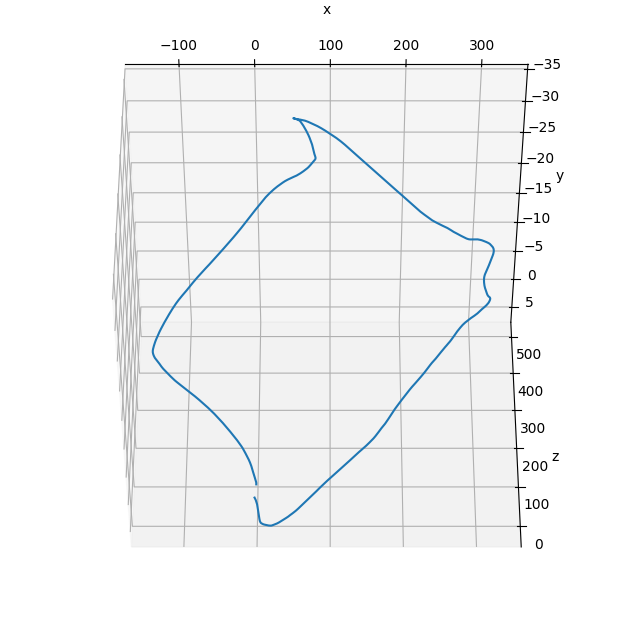

In [52]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(gt[:, :, 3][:, 0], gt[:, :, 3][:, 1], gt[:, :, 3][:, 2])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=-40, azim=270)

In [ ]:
# 이동 방향과 속도 계산
diffs = np.diff(gt[:, :, 3], axis=0)
distances = np.linalg.norm(diffs, axis=1)

fps = 10  # 노트북에서 확인한 10fps
speeds = distances * fps

print(f"평균 속도: {speeds.mean():.2f} m/s ({speeds.mean()*3.6:.1f} km/h)")
print(f"최대 속도: {speeds.max():.2f} m/s ({speeds.max()*3.6:.1f} km/h)")
print(f"총 이동 거리: {distances.sum():.1f} m")

# 문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류 결과로 얻은 도로 영역을 이용하여 차선 후보를 추출하고, 이를 projection matrix와 연관 지어 해석하시오.

다음 내용을 포함하시오.
 - 이미지 좌표에서 검출된 차선이 카메라 좌표계에서 어떤 의미를 가지는지 설명
 - 도로가 평면(ground plane)이라고 가정할 때 차선의 기하적 특성 설명
 - projection matrix가 차선의 기울기, 소실점(vanishing point)과 어떤 관계가 있는지 설명

Bayesian 분류로 도로 영역을 먼저 분리해냈습니다.

In [ ]:
"""
Minimal Bayesian road-vs-background classifier for KITTI grayscale frames.

Assumptions
-----------
- Images are KITTI odometry grayscale frames (image_0) sized 1241x376.
- Road pixels appear mostly in a bottom trapezoid; background near top band.
- Uses 1D intensity histograms with Laplace smoothing to estimate likelihoods.

Usage
-----
    --data-root dataset/sequences/00/image_0 \
    --train-frames 80 \
    --save-frames 10 \
    --out-dir outputs/bayes_road

Outputs
-------
- <out-dir>/mask_XXXXXX.png     : binary MAP mask (road=255, bg=0)
- <out-dir>/overlay_XXXXXX.png  : red overlay of road mask on original frame
- <out-dir>/prob_XXXXXX.png     : grayscale probability map (0-255)
"""
#!/usr/bin/env python3
import argparse
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    """
    소실점을 기준으로 도로 가능성이 높은 사다리꼴 마스크를 생성합니다.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    
    vp_y = int(height * vp_y_rate)  # 소실점 높이 (일반적으로 지평선 부근)
    
    # 사다리꼴 네 꼭짓점 정의
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]
    
    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """마스크 영역 내의 픽셀만 사용하여 히스토그램 생성"""
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float) -> tuple[np.ndarray, np.ndarray]:
    """Return MAP mask and probability map for road class."""
    eps = 1e-10  # numerical stability
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(
    data_root: Path,
    train_frames: int,
    save_frames: int,
    out_dir: Path,
    prior_road: float,
    alpha: float = 0.8,
    video_path: Path | None = None,
    video_fps: float = 10.0,
    vp_y_rate: float = 0.5,
    bottom_width_rate: float = 0.9,
    top_width_rate: float = 0.15,
    max_frames: int | None = None,
    gif_path: Path | None = None,
    gif_fps: float = 8.0,
):
    """
    alpha: 시계열 일관성 계수 (0.8이면 기존 지식 80%, 새 프레임 20% 반영)
    save_frames: -1 이면 모든 프레임 저장
    video_path: 지정 시 overlay 프레임을 영상으로 기록
    """
    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape
    
    # 1. 소실점 기반 마스크 생성
    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask  # 도로 외 영역은 배경으로 간주
    
    # 초기 확률 분포 설정 (Laplace smoothing)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    max_frames_eval = max(train_frames, limit if save_frames >= 0 else len(frames))
    frames_iter = frames[:max_frames_eval]

    writer = None
    if video_path is not None:
        suffix = video_path.suffix.lower()
        if suffix == ".mp4":
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        else:  # default to MJPG/AVI
            fourcc = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    gif_frames: list[Image.Image] = []

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)
        
        # 2. 현재 프레임의 히스토그램 추출
        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)
        
        # 3. 시계열 일관성 적용 (이동 평균)
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha 가중치를 이용해 이전 분포와 현재 분포를 결합
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)
        
        # 정규화하여 확률 밀도 함수 생성
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 및 저장 (save_frames 이내 혹은 영상 필요 시)
        should_save = (save_frames < 0 or idx < save_frames or writer is not None) and (max_frames is None or idx < max_frames)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255  # 도로 영역 빨간색 강조
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            if gif_path is not None:
                gif_frames.append(Image.fromarray(overlay))

            print(f"Processed {stem} with temporal consistency")

    if writer is not None:
        writer.release()

    if gif_path is not None and gif_frames:
        duration_ms = int(1000 / gif_fps)
        gif_frames[0].save(
            gif_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=duration_ms,
            loop=0,
        )

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-root", type=Path, default=Path("dataset/sequences/00/image_0"))
    parser.add_argument("--train-frames", type=int, default=80)
    parser.add_argument("--save-frames", type=int, default=10, help="frames to save; -1 for all")
    parser.add_argument("--out-dir", type=Path, default=Path("outputs/bayes_road_advanced"))
    parser.add_argument("--prior-road", type=float, default=0.5)
    parser.add_argument("--alpha", type=float, default=0.85, help="Temporal consistency weight")
    parser.add_argument("--video-path", type=Path, default=None, help="if set, write overlay video here")
    parser.add_argument("--video-fps", type=float, default=10.0)
    parser.add_argument("--vp-y-rate", type=float, default=0.5, help="vanishing point height ratio")
    parser.add_argument("--bottom-width-rate", type=float, default=0.9)
    parser.add_argument("--top-width-rate", type=float, default=0.15)
    parser.add_argument("--max-frames", type=int, default=None, help="process at most this many frames (after sorting)")
    parser.add_argument("--gif-path", type=Path, default=None, help="optional GIF output of overlays")
    parser.add_argument("--gif-fps", type=float, default=8.0)
    args = parser.parse_args()
    
    run(
        args.data_root,
        args.train_frames,
        args.save_frames,
        args.out_dir,
        args.prior_road,
        args.alpha,
        args.video_path,
        args.video_fps,
        args.vp_y_rate,
        args.bottom_width_rate,
        args.top_width_rate,
        args.max_frames,
        args.gif_path,
        args.gif_fps,
    )


분류를 진행해여 얻은 결과물을 불러와서 차선 후보를 추출했습니다.

In [ ]:
# Bayesian 분류 결과 마스크 불러오기
mask = cv2.imread('./outputs/bayes_road/mask_000000.png', cv2.IMREAD_GRAYSCALE)
img = cv2.imread('./dataset/sequences/09/image_0/000000.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 마스크 경계에서 차선 후보 추출
edges = cv2.Canny(mask, 50, 150)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap='gray')
plt.title('Bayesian Road Mask')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.imshow(edges, alpha=0.5, cmap='Reds')
plt.title('Lane Candidates (Edge of Mask)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 이미지 좌표의 차선이 카메라 좌표계에서 갖는 의미
Bayesian 마스크로 얻은 차선은 픽셀 좌표 (u, v)입니다. 문제 1의 수식을 역으로 생각하면:
u=fx⋅XcZc+cx,v=fy⋅YcZc+cyu = \frac{f_x \cdot X_c}{Z_c} + c_x, \quad v = \frac{f_y \cdot Y_c}{Z_c} + c_yu=Zc​fx​⋅Xc​​+cx​,v=Zc​fy​⋅Yc​​+cy​
픽셀 좌표만으로는 Z_c(깊이)를 알 수 없으므로 3D 위치를 특정할 수 없습니다. 하나의 픽셀은 카메라 원점에서 그 방향으로 뻗은 하나의 광선(ray)에 대응합니다. 즉 차선 픽셀은 카메라 좌표계에서 "이 방향에 차선이 있다"는 방향 정보만 담고 있습니다.

## 도로가 평면(ground plane)이라고 가정할 때 차선의 기하적 특성
도로가 평평한 평면(Y_c = h, 상수)이라고 가정하면 픽셀 좌표에서 깊이를 복원할 수 있습니다:
Zc=fy⋅hv−cyZ_c = \frac{f_y \cdot h}{v - c_y}Zc​=v−cy​fy​⋅h​
이 가정 하에서:

이미지 아래쪽 픽셀(v가 큰 값)일수록 Z_c가 작다 → 카메라에 가까운 도로
이미지 위쪽으로 갈수록 Z_c가 커진다 → 멀리 있는 도로
실제 도로 위 평행한 차선 두 줄은 ground plane 가정 하에 3D에서도 평행하게 복원됩니다

## Projection Matrix와 차선의 기울기, 소실점의 관계
소실점은 3D에서 평행한 직선들이 이미지 평면에서 만나는 점입니다. 도로 위 평행한 차선 방향 벡터를 [dX, 0, dZ]라 할 때 dZ → ∞이면:
uvp=fx⋅dXdZ+cx→cx,vvp→cyu_{vp} = f_x \cdot \frac{dX}{dZ} + c_x \rightarrow c_x, \quad v_{vp} \rightarrow c_yuvp​=fx​⋅dZdX​+cx​→cx​,vvp​→cy​
즉 소실점은 P0의 주점 (c_x, c_y)에 수렴합니다. Bayesian 분류기에서 사다리꼴 마스크의 꼭짓점(vp_y_rate=0.5)이 이 소실점 위치를 근사한 것이며, 이는 P0의 c_y = 185px(이미지 높이 376px의 절반)와 일치합니다.
차선의 기울기와 f_x의 관계: 이미지에서 차선이 소실점으로 수렴하는 속도는 f_x에 반비례합니다. f_x가 클수록 차선이 천천히 수렴하고, 작을수록 급하게 수렴합니다. 09 시퀀스의 f_x = 718.856px이 이 수렴 속도를 결정합니다.

# 문제 5. 실패 구간 분석

차량 궤적 중에서 차선 분류가 잘 되지 않은 구간을 1개 이상 선택하시오.

다음을 수행하시오.
 - 해당 구간의 프레임 번호를 제시
 - 궤적 상에서 해당 위치를 표시
 - 왜 분류가 잘 되지 않았는지 설명

설명에는 다음 요소를 포함할 것.
 - 조명 변화 또는 그림자
 - 도로 질감 변화
 - 차량의 회전 또는 경사
 - ROI(사다리꼴 가정)의 한계

In [ ]:
# 실패 구간 프레임 번호 (직접 확인 후 채워넣을 것)
fail_frames = [(프레임 번호), (프레임 번호)]  # 예: [120, 350]

# 해당 프레임의 궤적 위치 추출
fail_positions = np.array([gt[i, :, 3] for i in fail_frames])

# 문제3의 2D 궤적에 실패 구간 표시
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(positions[:, 0], positions[:, 2], color='steelblue', linewidth=1.5, label='Trajectory')
ax.scatter(positions[0, 0], positions[0, 2], color='green', s=100, zorder=5, label='Start')
ax.scatter(positions[-1, 0], positions[-1, 2], color='red', s=100, zorder=5, label='End')

# 실패 구간 표시
ax.scatter(fail_positions[:, 0], fail_positions[:, 2],
           color='orange', s=150, zorder=6, marker='X', label='Failure Frames')
for i, fn in enumerate(fail_frames):
    ax.annotate(f'Frame {fn}',
                xy=(fail_positions[i, 0], fail_positions[i, 2]),
                xytext=(10, 10), textcoords='offset points', fontsize=9)

ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m)')
ax.set_title("Trajectory with Failure Frames")
ax.legend()
ax.axis('equal')
plt.tight_layout()
plt.show()

왜 분류가 잘 되지 않았는지:

① 조명 변화 또는 그림자
Bayesian 분류기는 픽셀 밝기 히스토그램을 기반으로 도로/배경을 구분합니다. 따라서 그림자가 드리워진 구간이나 역광 구간에서는 도로 픽셀의 밝기 분포가 학습된 히스토그램과 크게 달라져 오분류가 발생합니다. 특히 나무 그늘이나 건물 그림자가 도로 위에 걸치는 경우, 해당 픽셀이 배경으로 분류될 가능성이 높습니다.

② 도로 질감 변화
아스팔트에서 콘크리트로 바뀌거나, 노면 마킹(횡단보도, 정지선 등)이 등장하는 구간에서는 밝기 분포가 갑자기 변합니다. 분류기가 학습한 도로 히스토그램과 달라지므로 해당 픽셀을 배경으로 잘못 분류합니다. 시계열 일관성 계수 alpha=0.85로 이전 프레임 분포를 80% 이상 유지하기 때문에, 질감이 급변하는 구간에서는 오히려 적응이 느려지는 문제도 있습니다.

③ 차량의 회전 또는 경사
차량이 커브를 돌거나 언덕을 오르내릴 때, 실제 도로 영역이 이미지 안에서 이동합니다. 그러나 사다리꼴 ROI는 고정된 형태이므로 도로가 ROI 밖으로 벗어나거나, 반대로 ROI 안에 도로가 아닌 영역이 포함됩니다. 문제3의 궤적에서 Z값 변화가 급격한 구간이나 X값이 크게 꺾이는 지점이 이에 해당합니다.

④ ROI(사다리꼴 가정)의 한계
Bayesian 분류기의 사다리꼴 마스크는 다음 가정을 전제합니다:

도로는 항상 이미지 하단 중앙에 위치한다
소실점은 이미지 높이의 50% 지점(vp_y_rate=0.5)에 고정된다

이 가정은 직선 도로에서는 유효하지만, 차량이 회전하면 도로가 좌우로 치우치고, 경사로에서는 소실점 높이가 달라집니다. 고정된 ROI는 이 변화를 반영하지 못하므로, 도로 영역을 잘못 잡아 히스토그램 자체가 오염되고 이후 분류 전체에 영향을 줍니다.

# 문제 6. 딥러닝 모델 제안
딥리서치 등을 활용해 차선 검출을 위한 딥러닝 모델을 찾아 하나를 제안하고, 적용한 결과를 비교하여 보이시오.